In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("/g/data/tm70/ml0072/COMMON/git_repos/fork_access-eval-recipes/ocean/simple_esmf_tools")

In [3]:
from esmfFileParser import *

In [4]:
from matplotlib import pyplot as plt
from matplotlib.colors import to_rgb
import numpy as np

In [5]:
ESMF_path = [
    "/g/data/tm70/ml0072/COMMON/git_repos/test_performance_eebde18/archive/output000",
    "/g/data/tm70/ml0072/COMMON/git_repos/test_performance/archive/output000",
    "/g/data/tm70/ml0072/COMMON/git_repos/test_performance2/archive/output000",
    "/g/data/tm70/ml0072/COMMON/git_repos/test_performance2_sr/archive/output000",
]

In [6]:
regionNames=[
    "[ESMF]",
    "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[OCN] RunPhase1",
    "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[ICE] RunPhase1",
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1',
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1',
    "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED]",
    "[ESMF]/[ensemble] Init 1",
]

In [7]:
# index for different profiling files (ESMF_Profile.xxxx or ESMF_Profile.summary)
# ESMF_Profile.xxxx   : (0. count, 1. total, 2. self_time, 3. mean    , 4. min_time, 5. max_time           )
# ESMF_Profile.summary: (0. count, 1. PETs , 2. mean     , 3. min_time, 4. max_time, 5. min_PET, 6. max_PET)
data_max = collect_runtime_tot(
    ESMF_path,
    regionNames=regionNames,
    profile_prefix="ESMF_Profile.",
    esmf_summary=True,
    index=4,
)

In [8]:
data_min = collect_runtime_tot(
    ESMF_path,
    regionNames=regionNames,
    profile_prefix="ESMF_Profile.",
    esmf_summary=True,
    index=3,
)

In [9]:
list(data_max[0].keys())

['[ESMF]',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[OCN] RunPhase1',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[ICE] RunPhase1',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_post_atm',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_prep_ocn_avg',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_prep_ocn_accum',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_post_ice',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_prep_ice',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_post_ocn',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_aofluxes_run',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_ocnalb_run',
 '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_pha

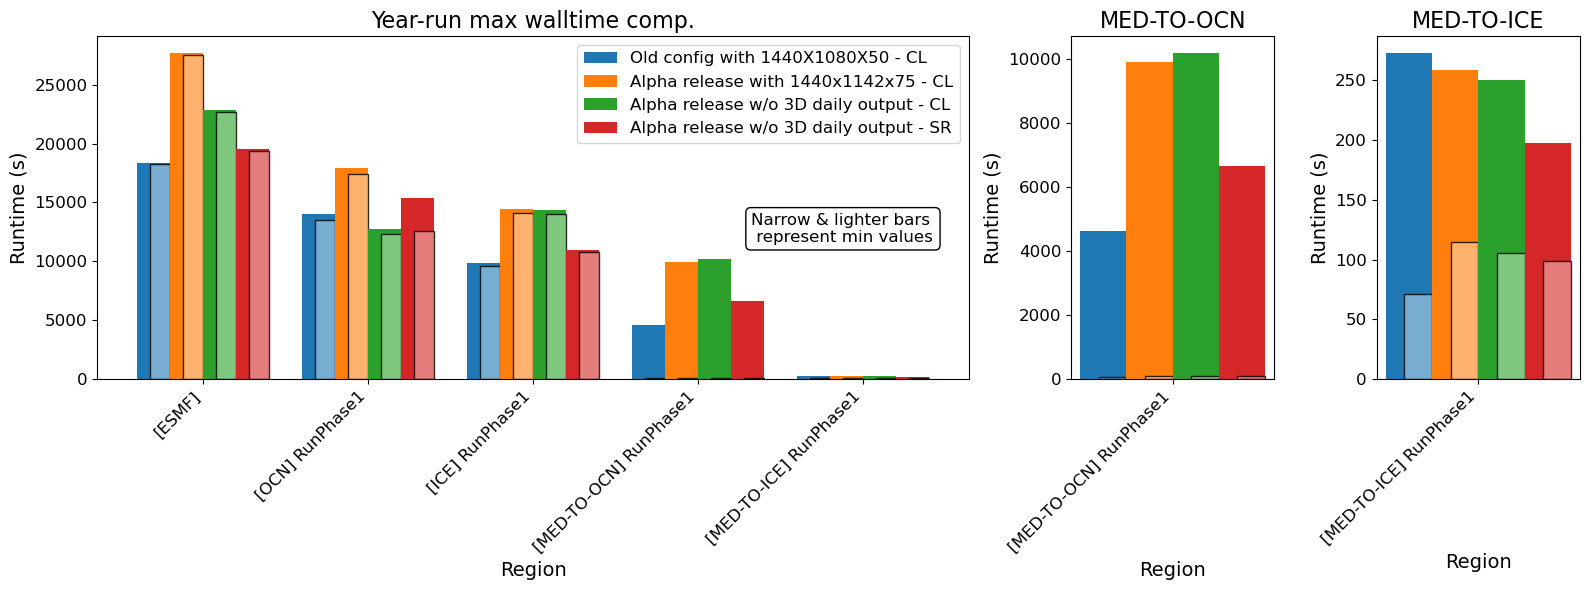

In [10]:
configs = [
    "Old config with 1440X1080X50 - CL",
    "Alpha release with 1440x1142x75 - CL",
    "Alpha release w/o 3D daily output - CL",
    "Alpha release w/o 3D daily output - SR"
]

keys_main = [
    '[ESMF]',
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[OCN] RunPhase1',
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[ICE] RunPhase1',
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1',
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1',
]

med_to_ocean = [
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1',
]

med_to_ice = [
    '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1',
]

bar_width = 0.8 / len(configs)
mean_bar_width = bar_width * 0.6

def lighten_color(color, factor=0.5):
    r, g, b = to_rgb(color)
    return (r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 0.7, 0.7]})

for ax, keys, title in zip([ax1, ax2, ax3], [keys_main, med_to_ocean, med_to_ice], ["Year-run max walltime comp.", "MED-TO-OCN", "MED-TO-ICE"]):
    n_keys = len(keys)
    index = np.arange(n_keys)

    for i in range(len(configs)):
        values_max = [data_max[i][k][0] for k in keys]
        values_min = [data_min[i][k][0] for k in keys]

        x_max = index + i * bar_width
        x_min = x_max + (bar_width - mean_bar_width) / 2

        container = ax.bar(x_max, values_max, bar_width, label=configs[i] if ax == ax1 else None)
        face_color = container.patches[0].get_facecolor()
        lighter_color = lighten_color(face_color, 0.5)

        ax.bar(
            x_min,
            values_min,
            mean_bar_width,
            alpha=0.8,
            color=lighter_color,
            edgecolor='black',
            linewidth=1.0,
        )

    ax.set_xticks(index + bar_width * (len(configs) - 1) / 2)
    ax.set_xticklabels([k.split("/")[-1] for k in keys], rotation=45, ha='right', fontsize=13)
    ax.set_xlabel("Region", fontsize=14)
    ax.set_ylabel("Runtime (s)", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='both', labelsize=12)

ax1.legend(fontsize=12)
ax1.annotate(
    "Narrow & lighter bars \n represent min values",
    xy=(0.75, 0.4), xycoords='axes fraction',
    fontsize=12,
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=1),
    arrowprops=dict(arrowstyle="->", color="gray")
)
plt.tight_layout()
plt.show()

In [11]:
# index for different profiling files (ESMF_Profile.xxxx or ESMF_Profile.summary)
# ESMF_Profile.xxxx   : (0. count, 1. total, 2. self_time, 3. mean    , 4. min_time, 5. max_time           )
# ESMF_Profile.summary: (0. count, 1. PETs , 2. mean     , 3. min_time, 4. max_time, 5. min_PET, 6. max_PET)
runtime_total = collect_runtime_tot(
    ESMF_path,
    regionNames=regionNames,
    profile_prefix="ESMF_Profile.",
    esmf_summary=False,
    index=1,
)

In [12]:
runtime_total[0].keys()

dict_keys(['[ESMF]', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[OCN] RunPhase1', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[ICE] RunPhase1', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_post_atm', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_prep_ocn_avg', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_prep_ocn_accum', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_post_ice', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_prep_ice', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_post_ocn', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_restart_write', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_diag_atm', '[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED] med_phases_

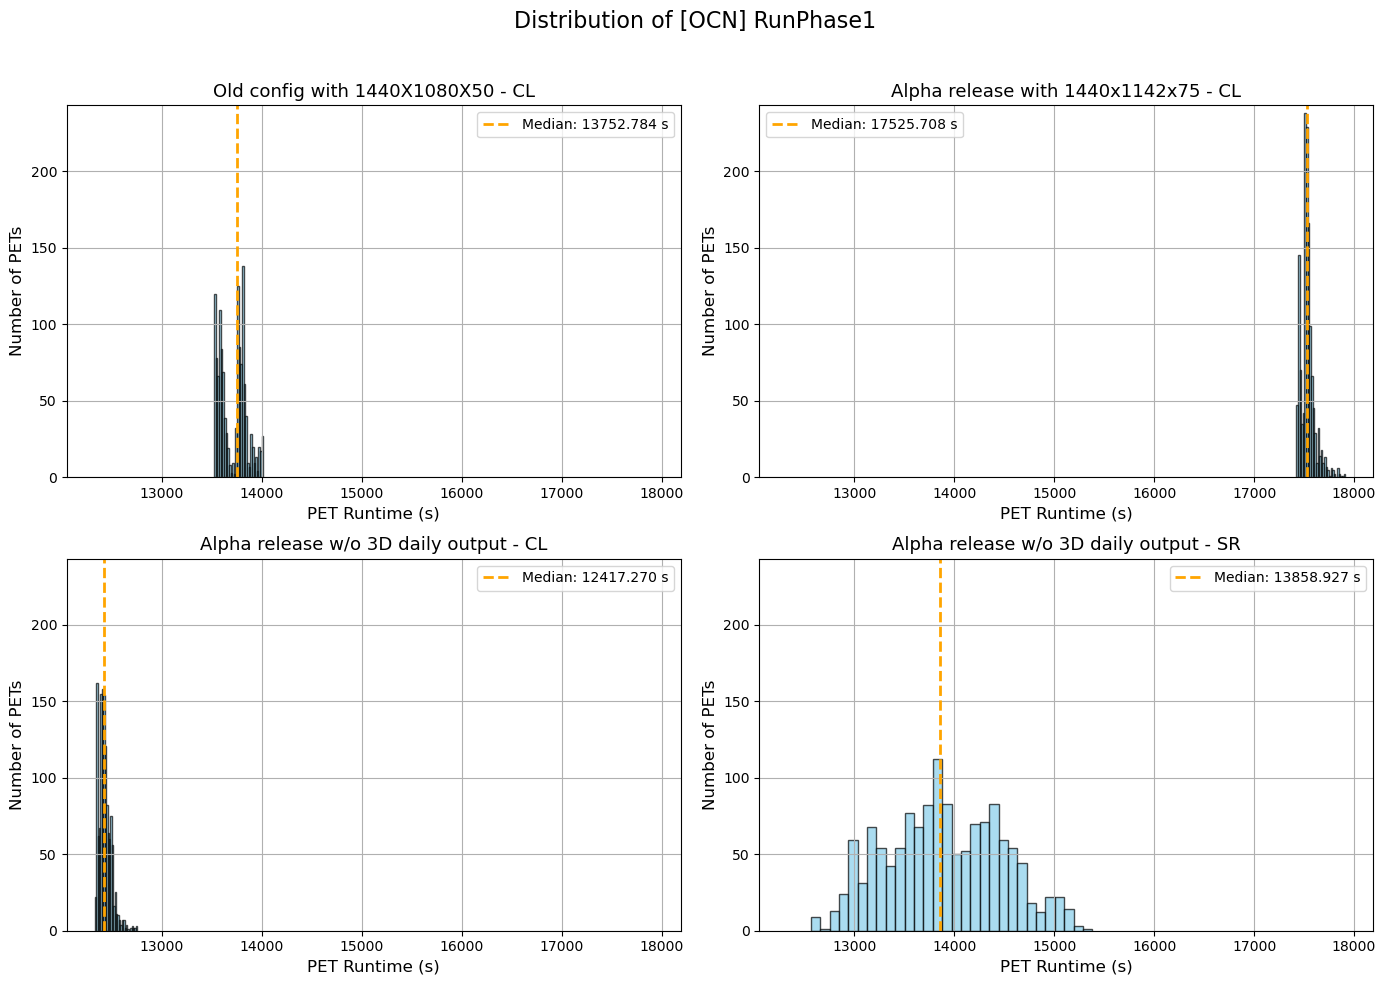

In [13]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[OCN] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
combined = np.concatenate(all_values)
x_min, x_max = np.min(combined), np.max(combined)
x_padding = 0.05 * (x_max - x_min)
xlim = (x_min - x_padding, x_max + x_padding)

hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)
    # ax.text(arr_median * 1.05, ax.get_ylim()[1]*0.9,
    #         f'{below_median} PETs < median',
    #         color='orange', fontsize=10)
    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

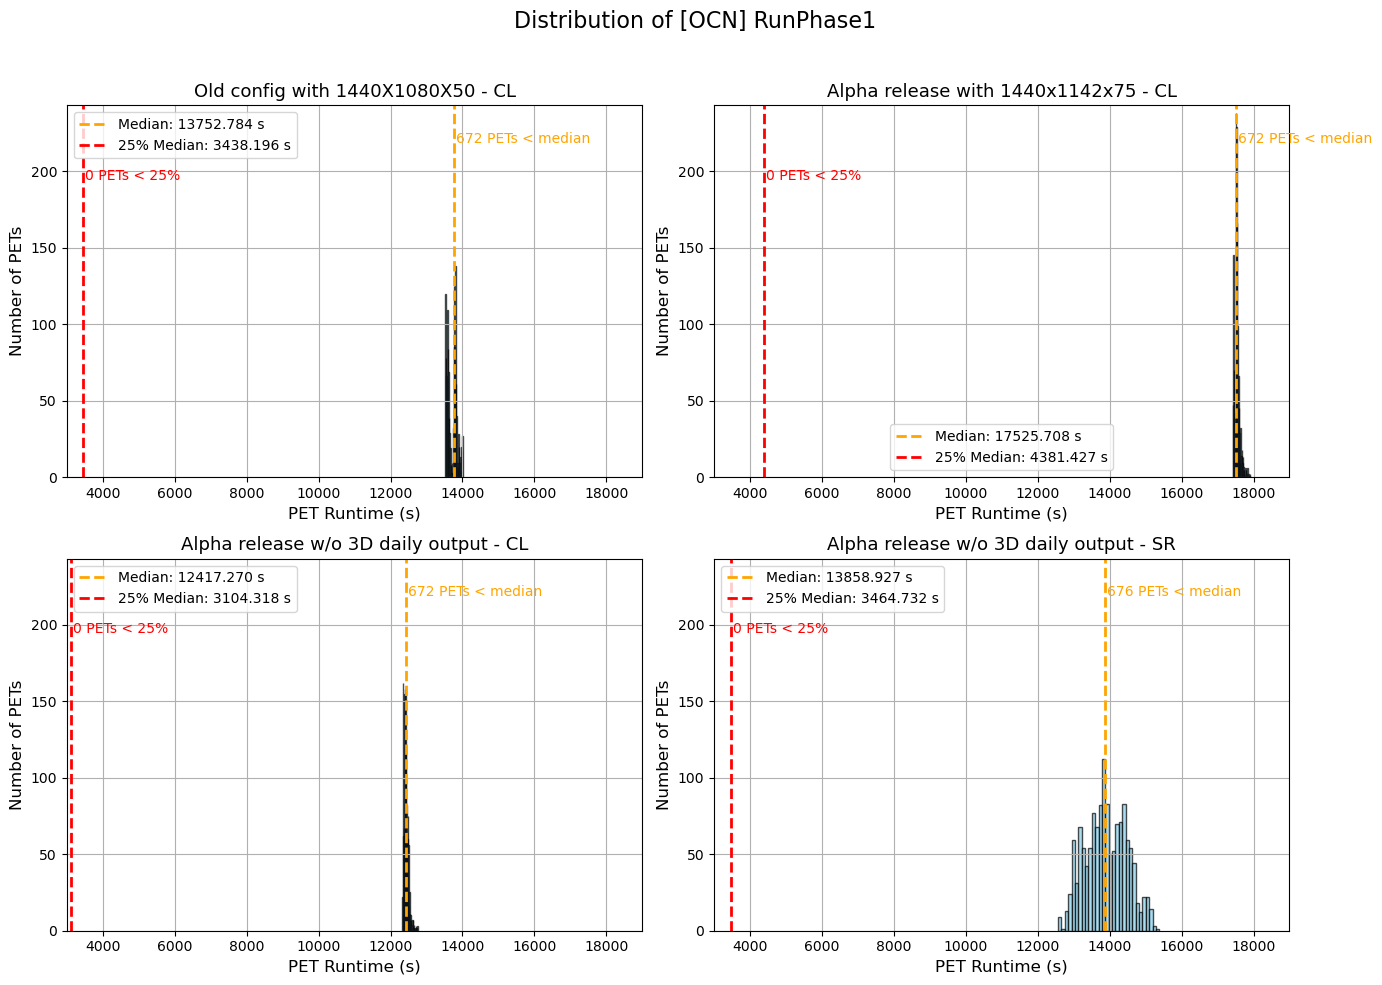

In [14]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[OCN] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
xlim = (3000, 19000)
hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)

    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')
    ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
               label=f'25% Median: {threshold:.3f} s')

    ax.text(arr_median + 0.01 * (x_max - x_min), ylim[1]*0.9,
            f'{below_median} PETs < median',
            color='orange', fontsize=10)
    ax.text(threshold + 0.01 * (x_max - x_min), ylim[1]*0.8,
            f'{below_threshold} PETs < 25%',
            color='red', fontsize=10)

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

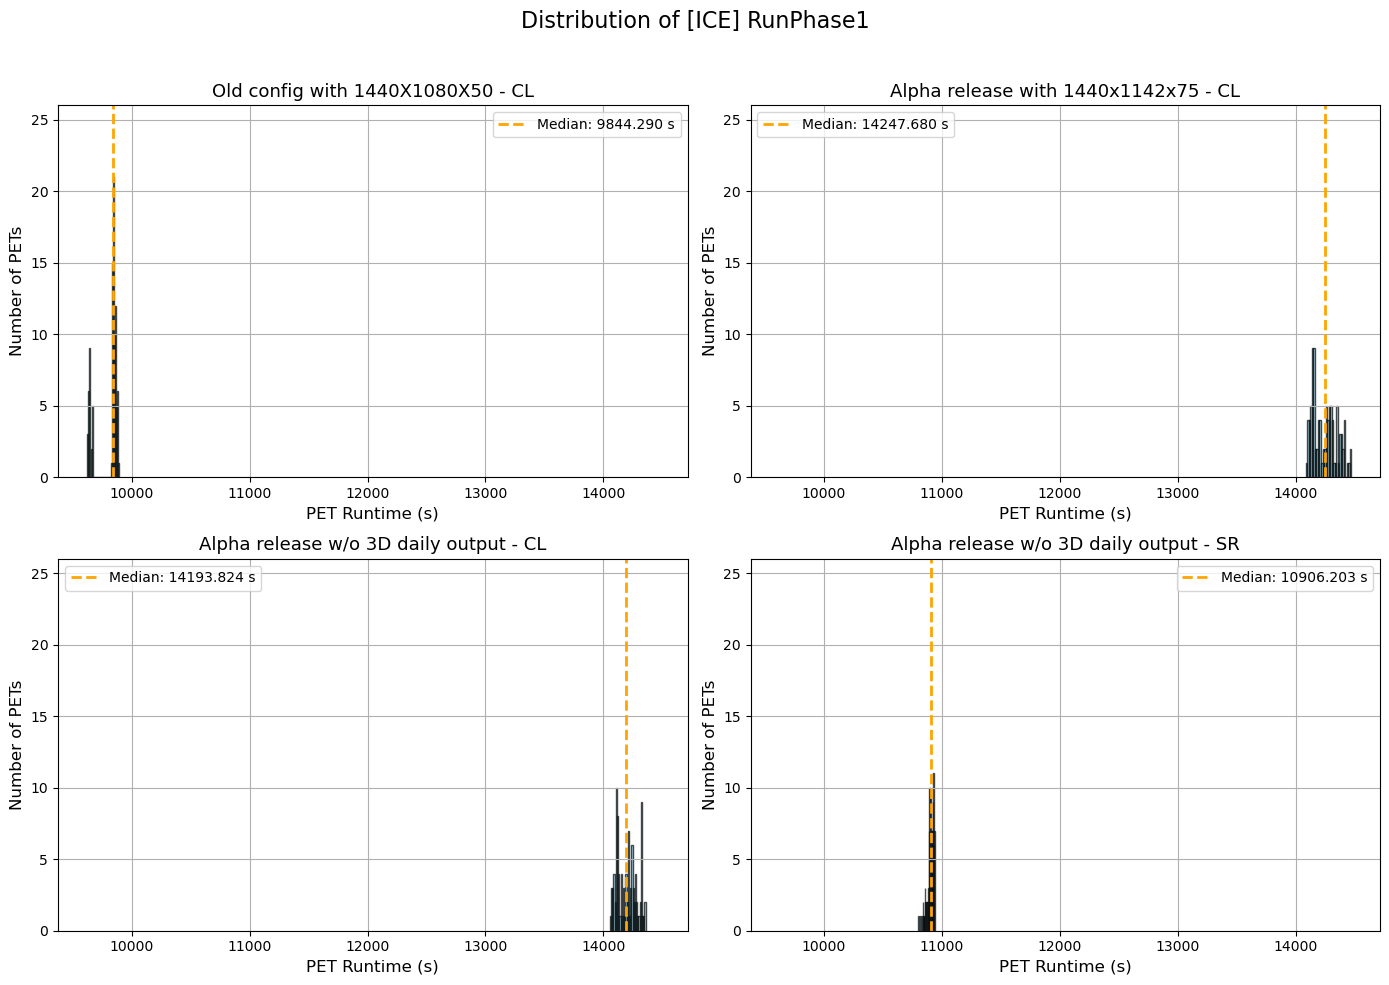

In [15]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[ICE] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
combined = np.concatenate(all_values)
x_min, x_max = np.min(combined), np.max(combined)
x_padding = 0.05 * (x_max - x_min)
xlim = (x_min - x_padding, x_max + x_padding)
hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)
    # ax.text(arr_median * 1.05, ax.get_ylim()[1]*0.9,
    #         f'{below_median} PETs < median',
    #         color='orange', fontsize=10)
    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

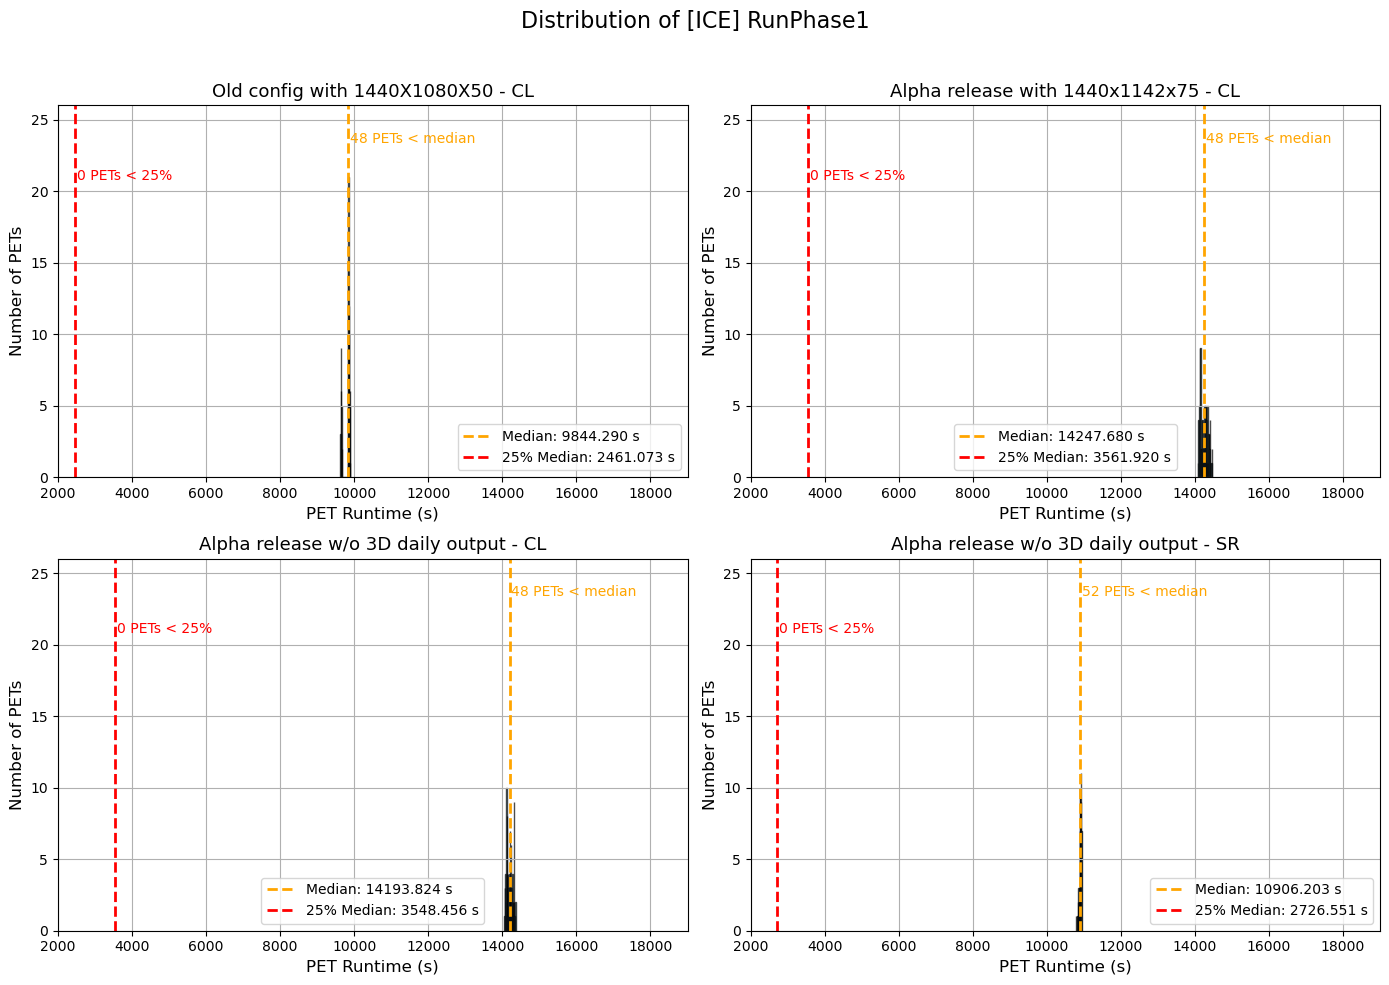

In [16]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[ICE] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
xlim = (2000, 19000)
hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)

    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')
    ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
               label=f'25% Median: {threshold:.3f} s')

    ax.text(arr_median + 0.01 * (x_max - x_min), ylim[1]*0.9,
            f'{below_median} PETs < median',
            color='orange', fontsize=10)
    ax.text(threshold + 0.01 * (x_max - x_min), ylim[1]*0.8,
            f'{below_threshold} PETs < 25%',
            color='red', fontsize=10)

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

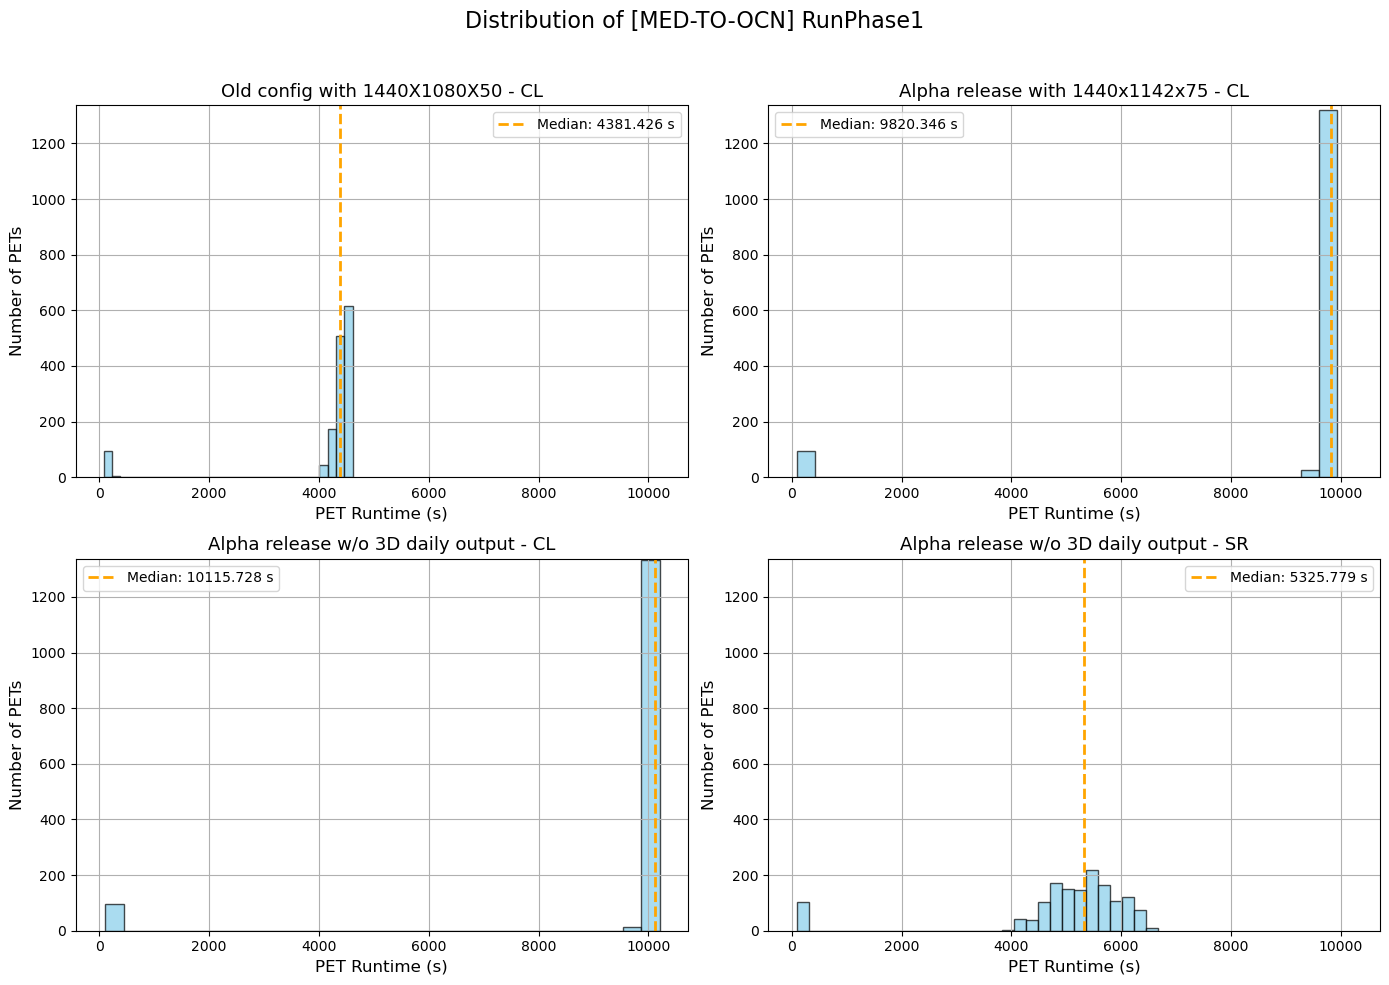

In [17]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
combined = np.concatenate(all_values)
x_min, x_max = np.min(combined), np.max(combined)
x_padding = 0.05 * (x_max - x_min)
xlim = (x_min - x_padding, x_max + x_padding)
hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)
    # ax.text(arr_median * 1.05, ax.get_ylim()[1]*0.9,
    #         f'{below_median} PETs < median',
    #         color='orange', fontsize=10)
    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

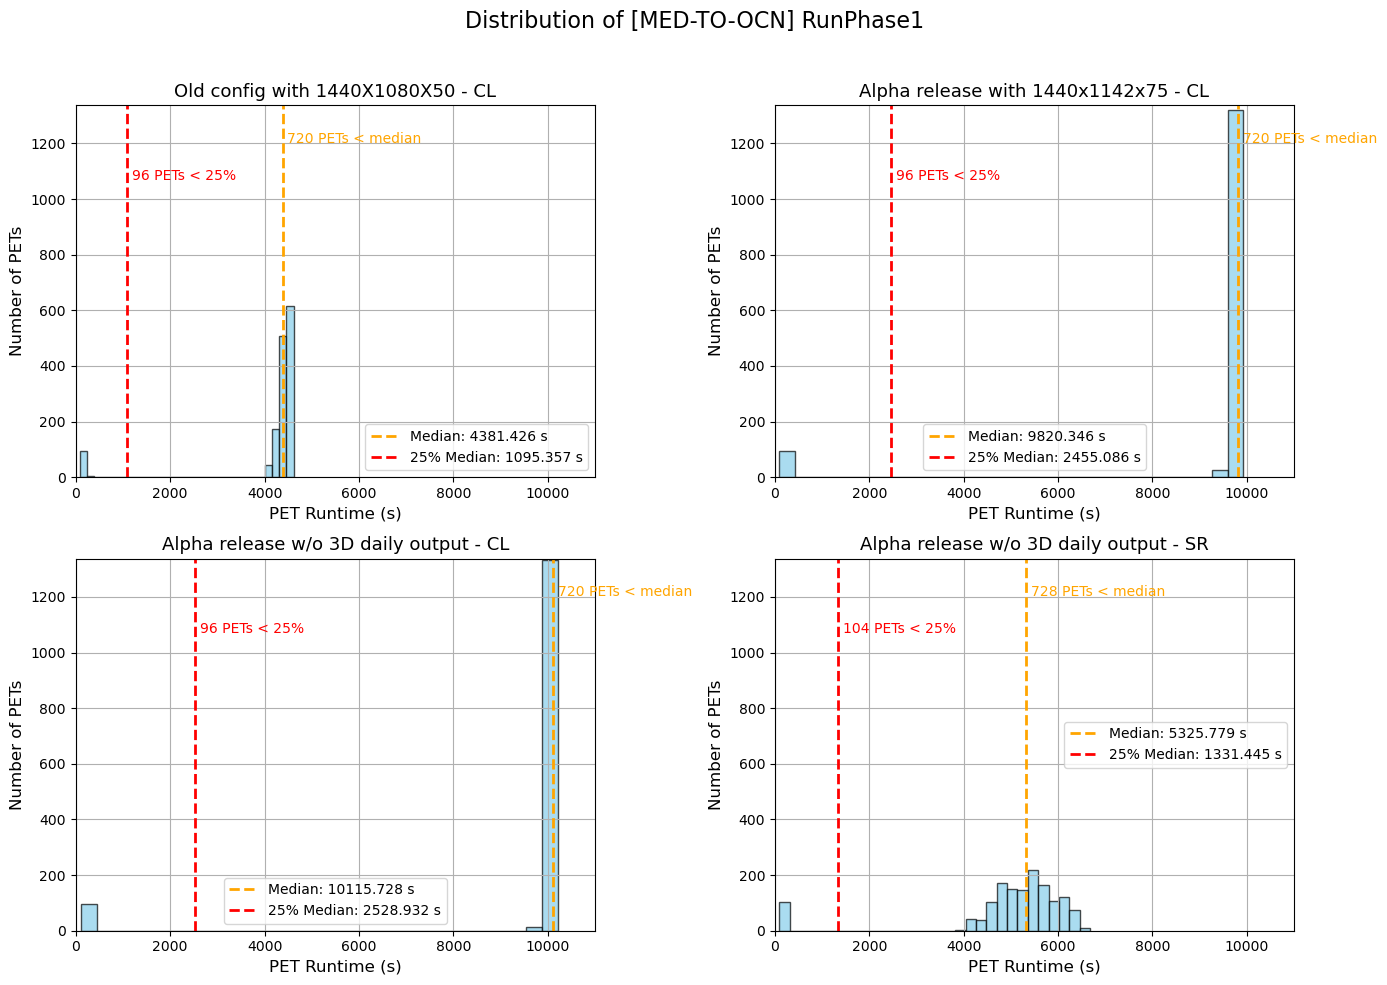

In [18]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
xlim = (0, 11000)
hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)

    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')
    ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
               label=f'25% Median: {threshold:.3f} s')

    ax.text(arr_median + 0.01 * (x_max - x_min), ylim[1]*0.9,
            f'{below_median} PETs < median',
            color='orange', fontsize=10)
    ax.text(threshold + 0.01 * (x_max - x_min), ylim[1]*0.8,
            f'{below_threshold} PETs < 25%',
            color='red', fontsize=10)

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

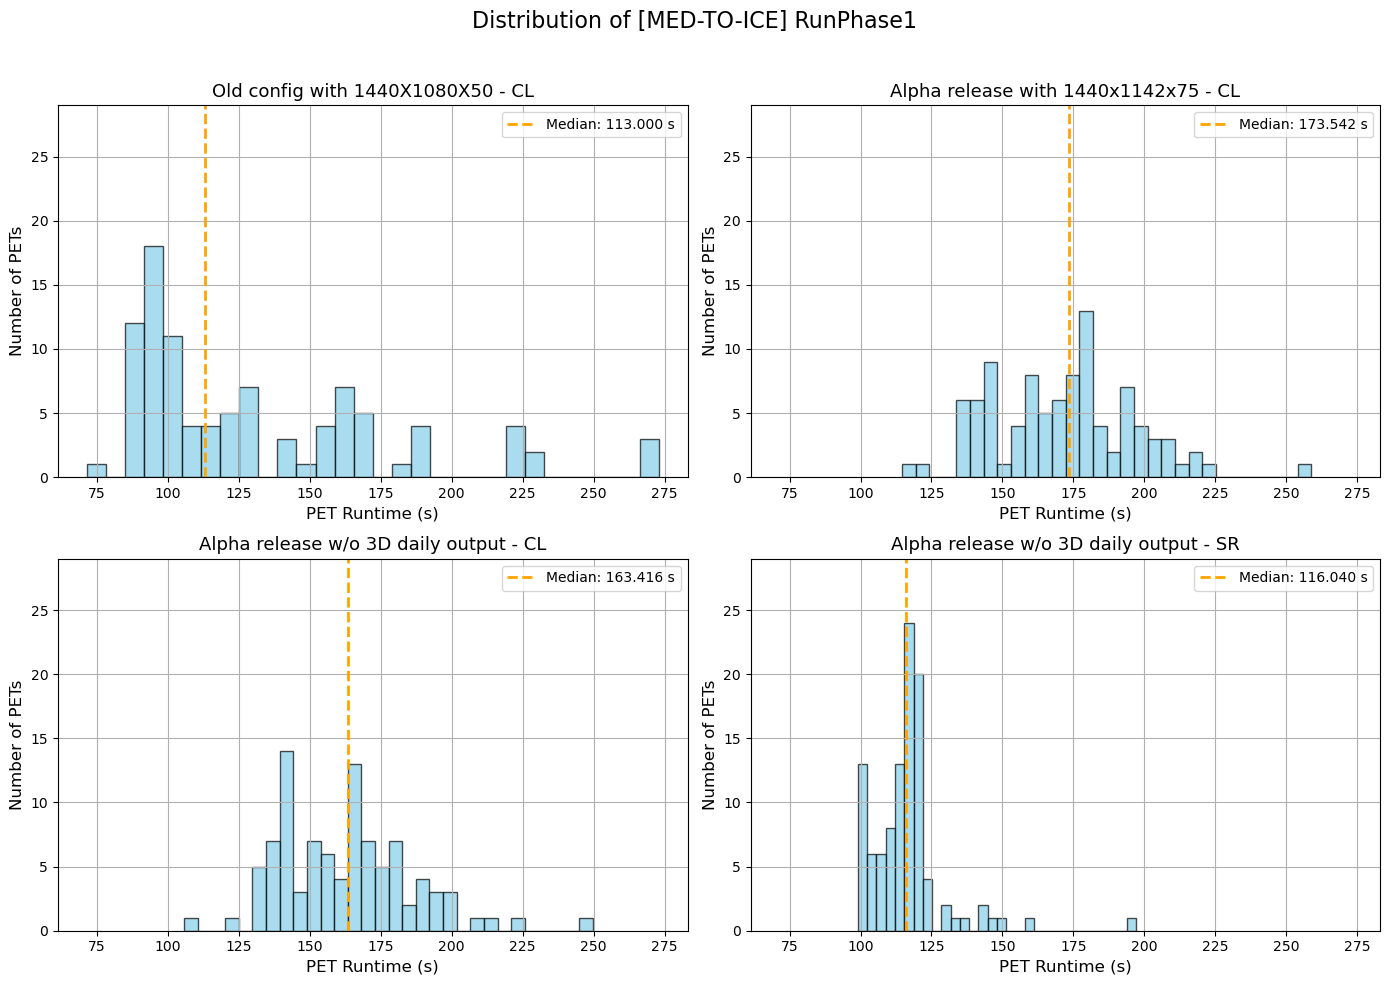

In [19]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
combined = np.concatenate(all_values)
x_min, x_max = np.min(combined), np.max(combined)
x_padding = 0.05 * (x_max - x_min)
xlim = (x_min - x_padding, x_max + x_padding)
hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)
    # ax.text(arr_median * 1.05, ax.get_ylim()[1]*0.9,
    #         f'{below_median} PETs < median',
    #         color='orange', fontsize=10)
    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

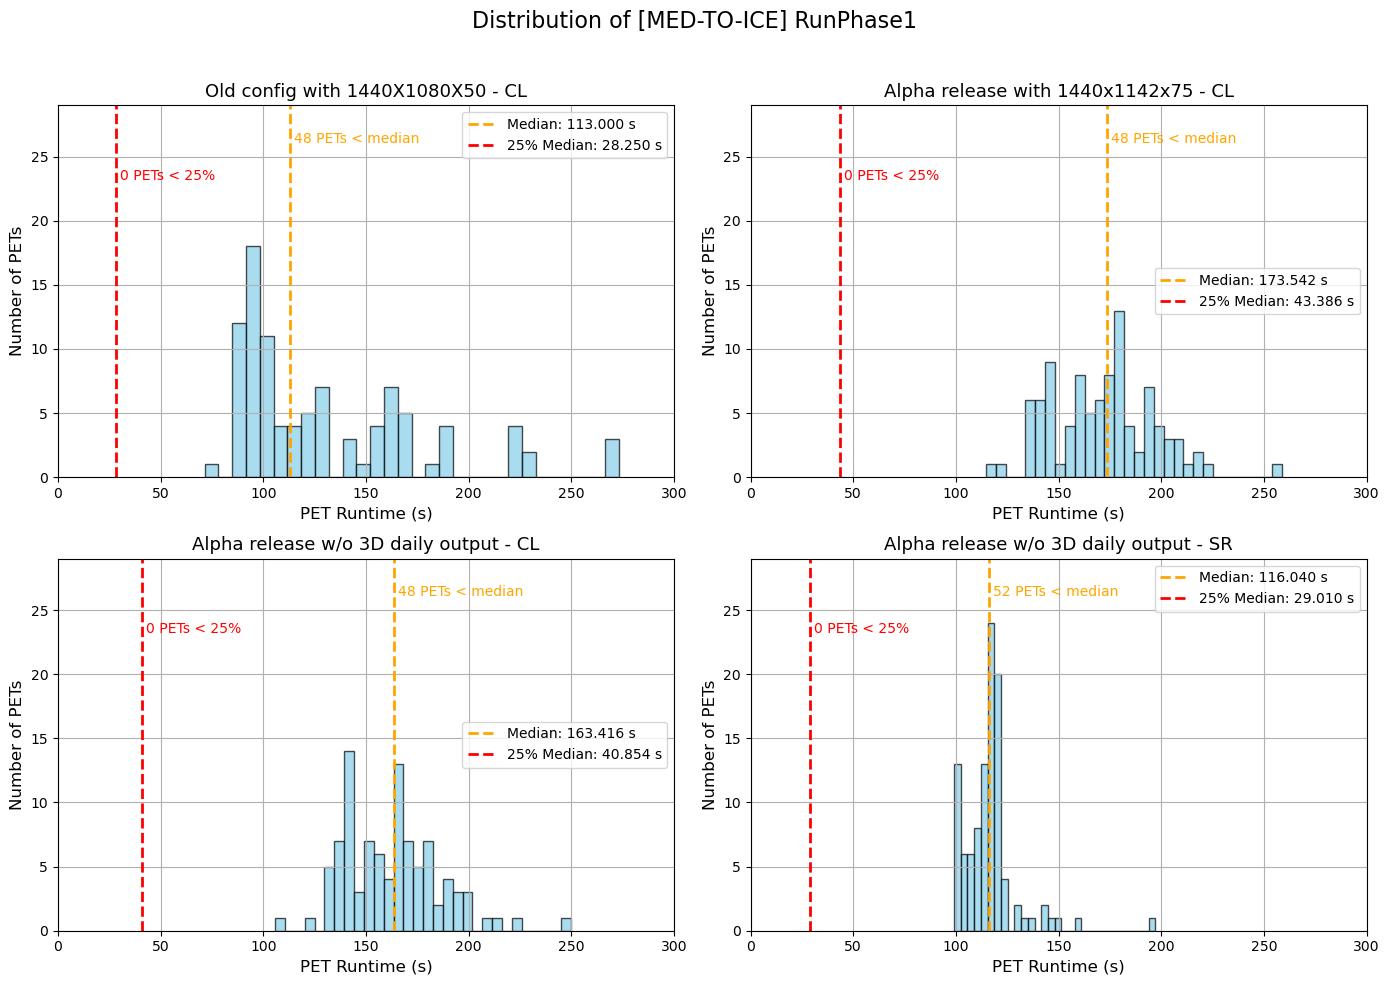

In [20]:
phase_key = "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1"

all_values = [np.array(runtime_total[i][phase_key]) for i in range(4)]
xlim = (0, 300)
hist_max_y = 0
for arr in all_values:
    hist, _ = np.histogram(arr, bins=30)
    hist_max_y = max(hist_max_y, max(hist))
ylim = (0, hist_max_y + 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    arr = all_values[i]
    arr_median = np.median(arr)
    threshold = 0.25 * arr_median

    below_median = np.sum(arr < arr_median)
    below_threshold = np.sum(arr < threshold)

    ax = axes[i]
    ax.hist(arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f'{configs[i]}', fontsize=13)
    ax.set_xlabel('PET Runtime (s)', fontsize=12)
    ax.set_ylabel('Number of PETs', fontsize=12)

    ax.axvline(arr_median, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {arr_median:.3f} s')
    ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
               label=f'25% Median: {threshold:.3f} s')

    ax.text(arr_median + 0.01 * (x_max - x_min), ylim[1]*0.9,
            f'{below_median} PETs < median',
            color='orange', fontsize=10)
    ax.text(threshold + 0.01 * (x_max - x_min), ylim[1]*0.8,
            f'{below_threshold} PETs < 25%',
            color='red', fontsize=10)

    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle(f"Distribution of {phase_key.split('/')[-1]}", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

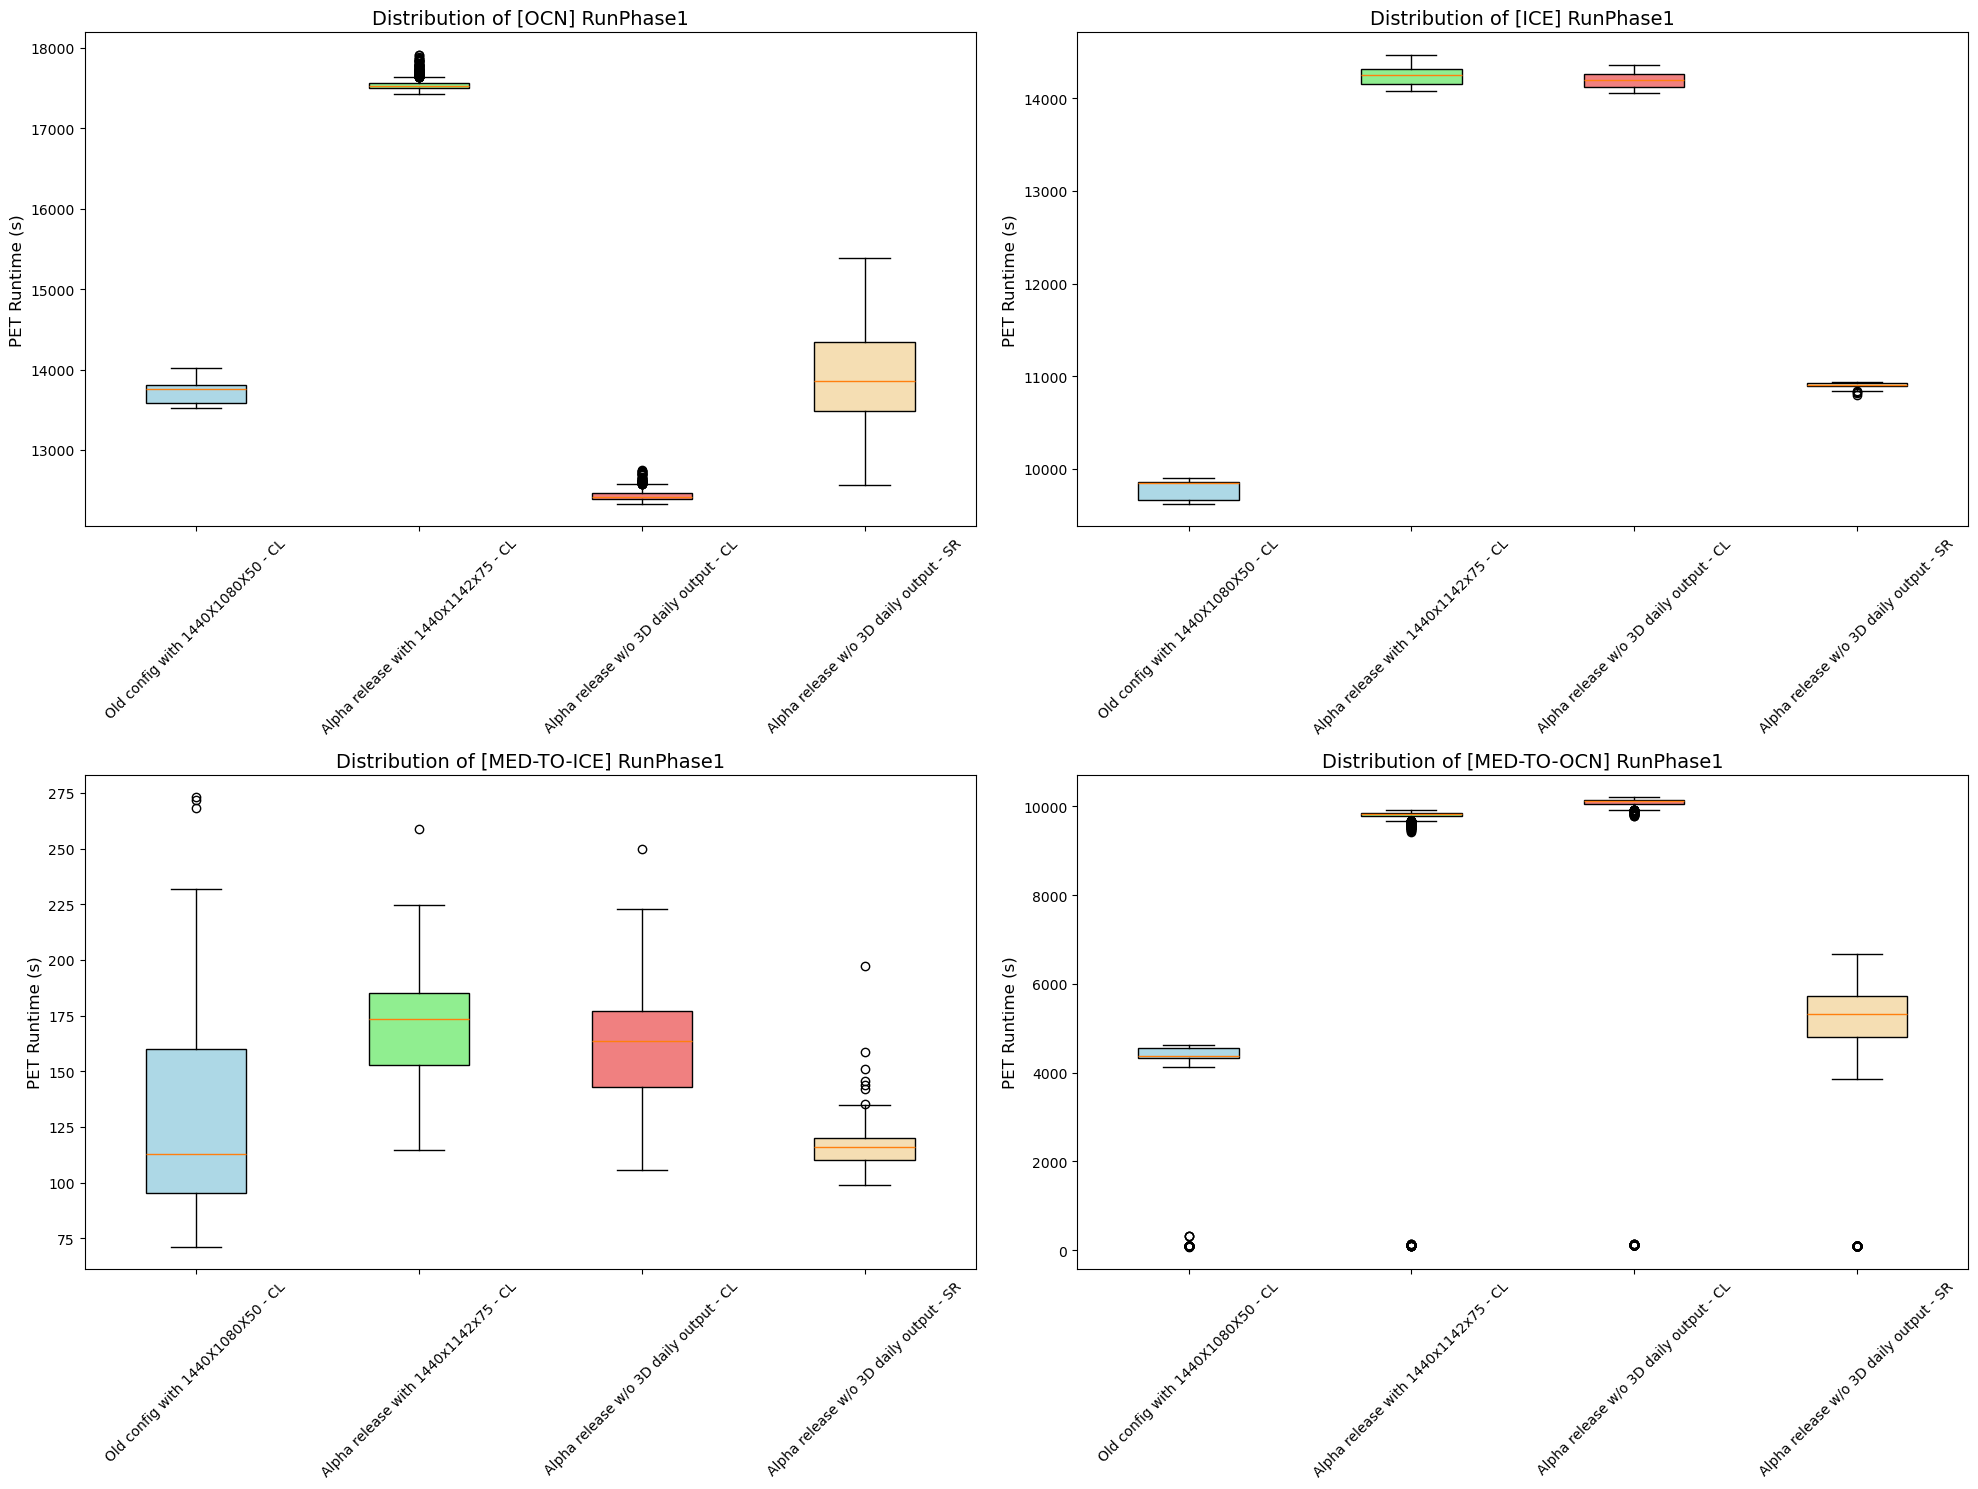

In [21]:
phase_keys = [
    "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[OCN] RunPhase1",
    "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[ICE] RunPhase1",
    "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-ICE] RunPhase1",
    "[ESMF]/[ensemble] RunPhase1/[ESM0001] RunPhase1/[MED-TO-OCN] RunPhase1",
]

titles = [
    "[OCN] RunPhase1",
    "[ICE] RunPhase1",
    "[MED-TO-ICE] RunPhase1",
    "[MED-TO-OCN] RunPhase1"
]

colors = ['lightblue', 'lightgreen', 'lightcoral', 'wheat']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))
axes = axes.flatten()

for idx, key in enumerate(phase_keys):
    all_data = [runtime_total[i][key] for i in range(4)]
    box = axes[idx].boxplot(all_data, tick_labels=configs, patch_artist=True, showfliers=True)

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    axes[idx].set_title(f"Distribution of {titles[idx]}", fontsize=14)
    axes[idx].set_ylabel("PET Runtime (s)", fontsize=12)
    axes[idx].tick_params(axis='x', labelrotation=45)
    axes[idx].tick_params(labelsize=10)
plt.tight_layout()
plt.show()